# **ACS Demographics + Opportunity (Tract-level) Notebook**
### **Author: Lauren Vo**
**Updated: Dec 16, 2025**

This notebook builds tract-level demographic and socioeconomic indicators for **San Diego County** using **ACS 5-year (2023)** tract tables downloaded from `data.census.gov`, then joins them to **TIGER/Line Census Tracts** for mapping.

Because the **Child Opportunity Index (COI)** is not an ACS table, we compute an **ACS-based proxy “Opportunity Index”** from a small set of tract indicators (income, poverty, no-vehicle, internet). If we later add a real COI dataset, this notebook can also join and map it.

**Inputs**
- `data/raw/acs/2023/*.zip` (downloaded ACS tables)
- `data/external/tiger_tracts_2023/tl_2023_06_tract.zip`

**Outputs**
- `data/processed/acs/acs_tract_indicators.csv`
- `data/processed/acs/acs_tract_indicators.geojson`
- `data/processed/acs/acs_tract_maps.html`

**Key notes / assumptions**
- This expects **tract-level** ACS files (not county/state summaries).
- Filters to **San Diego County tracts (STATEFP=06, COUNTYFP=073)** using TIGER.
- Extracts `tract_geoid` (11-digit) from ACS `GEO_ID`.
- Excludes **no-population tracts** (`total_population == 0`) from analysis/visualization.
- For the remaining tracts, any missing indicator values are imputed using the **county median** (only for the missing entries).

**How to read the maps**
- Choropleths are binned into **quantiles** and shown using **discrete Tableau-like colors** (not a gradient).
- Median household income and the Opportunity Index: higher values indicate higher advantage (better outcomes).
- Poverty rate, % households with zero vehicles, and % households with no internet subscription: higher values indicate higher constraint (worse outcomes).

In [130]:
from pathlib import Path
import zipfile
import re
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

warnings.filterwarnings("ignore", category=UserWarning)

try:
    import folium
except ImportError as e:
    raise ImportError("Missing folium. Install with: pip install folium") from e


In [131]:
# Project root detection 
candidates = [
    Path("."),
    Path(".."),
    Path("../.."),
    Path("../../.."),
    Path("../../../.."),
]

PROJECT_ROOT = None
for cand in candidates:
    cand = cand.resolve()
    if (cand / "data" / "raw" / "acs" / "2023").exists() and (cand / "data" / "external" / "tiger_tracts_2023").exists():
        PROJECT_ROOT = cand
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Could not find required directories from this notebook location:\n"
        "- data/raw/acs/2023\n"
        "- data/external/tiger_tracts_2023\n"
        "Move this notebook inside the Mapping-Youth-Opportunity-Deserts repo and try again."
    )

print("Using PROJECT_ROOT:", PROJECT_ROOT)

DATA_DIR = PROJECT_ROOT / "data"

RAW_ACS_DIR = DATA_DIR / "raw" / "acs" / "2023"
INTERIM_ACS_DIR = DATA_DIR / "interim" / "acs" / "2023"
PROCESSED_ACS_DIR = DATA_DIR / "processed" / "acs"

INTERIM_ACS_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_ACS_DIR.mkdir(parents=True, exist_ok=True)

EXTERNAL_TIGER_DIR = DATA_DIR / "external" / "tiger_tracts_2023"
TRACT_ZIP = EXTERNAL_TIGER_DIR / "tl_2023_06_tract.zip"

OUT_CSV = PROCESSED_ACS_DIR / "acs_tract_indicators.csv"
OUT_GEOJSON = PROCESSED_ACS_DIR / "acs_tract_indicators.geojson"
OUT_HTML = PROCESSED_ACS_DIR / "acs_tract_maps.html"

RAW_ACS_DIR, TRACT_ZIP


Using PROJECT_ROOT: /Users/laurenvo/Documents/github/Mapping-Youth-Opportunity-Deserts


(PosixPath('/Users/laurenvo/Documents/github/Mapping-Youth-Opportunity-Deserts/data/raw/acs/2023'),
 PosixPath('/Users/laurenvo/Documents/github/Mapping-Youth-Opportunity-Deserts/data/external/tiger_tracts_2023/tl_2023_06_tract.zip'))

In [132]:
# Unzip all ACS tables (into data/interim/acs/2023/extracted/<zipname>/)
EXTRACT_DIR = INTERIM_ACS_DIR / "extracted"
EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

zip_paths = sorted(RAW_ACS_DIR.glob("*.zip"))
print("ACS zip files found:", len(zip_paths))

for z in zip_paths:
    out_dir = EXTRACT_DIR / z.stem
    out_dir.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(z, "r") as zf:
        zf.extractall(out_dir)

print("Extracted to:", EXTRACT_DIR)


ACS zip files found: 8
Extracted to: /Users/laurenvo/Documents/github/Mapping-Youth-Opportunity-Deserts/data/interim/acs/2023/extracted


In [133]:
# Load tracts (San Diego County)
if not TRACT_ZIP.exists():
    raise FileNotFoundError(f"Missing: {TRACT_ZIP}")

tracts = gpd.read_file(TRACT_ZIP)
tracts = tracts.set_crs(tracts.crs or "EPSG:4269", allow_override=True).to_crs("EPSG:4326")

tracts_sd = tracts[(tracts["STATEFP"] == "06") & (tracts["COUNTYFP"] == "073")].copy()
tracts_sd = tracts_sd[["GEOID", "NAME", "NAMELSAD", "geometry"]].rename(columns={"GEOID": "tract_geoid"})

print("San Diego tracts:", len(tracts_sd))
tracts_sd.head(2)


San Diego tracts: 737


,tract_geoid,NAME,NAMELSAD,geometry
810,06073008331,83.31,Census Tract 83.31,"POLYGON ((-117.23082 32.94176, -117.23079 32.9..."
819,06073008336,83.36,Census Tract 83.36,"POLYGON ((-117.13793 32.96927, -117.13792 32.9..."


In [134]:
# Helpers: ACS CSV loading + GEOID extraction
TRACT_RE = re.compile(r"(\d{11})$")

def extract_tract_geoid(x: str):
    if pd.isna(x):
        return np.nan
    s = str(x)
    m = TRACT_RE.search(s)
    return m.group(1) if m else np.nan

def find_first_data_csv(folder: Path) -> Path | None:
    # data.census.gov zips usually contain a "*Data*.csv"
    cands = list(folder.rglob("*Data*.csv"))
    if cands:
        return sorted(cands)[0]
    # fallback: first .csv
    cands = list(folder.rglob("*.csv"))
    return sorted(cands)[0] if cands else None

def load_acs_table(extracted_folder: Path, table_hint: str):
    """
    Loads a single ACS table from an extracted zip folder into a DataFrame.
    Returns df with a 'tract_geoid' column.
    """
    csv_path = find_first_data_csv(extracted_folder)
    if csv_path is None:
        print(f"[WARN] No CSV found for {table_hint} in {extracted_folder}")
        return None

    df = pd.read_csv(csv_path, dtype=str)

    # Try to standardize the geography id column
    geo_col = None
    for c in ["GEO_ID", "GEOID", "Geography", "geography", "geo_id"]:
        if c in df.columns:
            geo_col = c
            break

    if geo_col is None:
        print(f"[WARN] Could not find GEO_ID-like column in {csv_path.name}")
        return None

    df["tract_geoid"] = df[geo_col].map(extract_tract_geoid)

    # Keep only SD tracts
    df = df[df["tract_geoid"].isin(set(tracts_sd["tract_geoid"]))].copy()

    df["_source_table"] = table_hint
    return df


In [135]:
# Load all extracted tables into a dict
tables = {}  # key: table code like "DP05" or "B19013" etc

for folder in sorted(EXTRACT_DIR.iterdir()):
    if not folder.is_dir():
        continue

    name = folder.name

    m = re.search(r"(DP\d{2}|B\d{5}|S\d{4})", name)
    table_code = m.group(1) if m else name

    df = load_acs_table(folder, table_code)
    if df is not None and len(df) > 0:
        tables[table_code] = df

print("Loaded tables:", sorted(tables.keys()))
[(k, tables[k].shape) for k in sorted(tables.keys())]


Loaded tables: ['B08201', 'B19013', 'B28002', 'DP05', 'S0101', 'S1401', 'S1701', 'S2201']


[('B08201', (737, 65)),
 ('B19013', (737, 7)),
 ('B28002', (737, 31)),
 ('DP05', (737, 381)),
 ('S0101', (737, 461)),
 ('S1401', (737, 413)),
 ('S1701', (737, 377)),
 ('S2201', (737, 461))]

In [136]:
# Helpers: pick estimate columns robustly
def pick_col_by_regex(df: pd.DataFrame, patterns: list[str]):
    cols = list(df.columns)
    for pat in patterns:
        r = re.compile(pat, flags=re.IGNORECASE)
        hits = [c for c in cols if r.search(c)]
        if hits:
            return hits[0]
    return None

def to_num(s):
    return pd.to_numeric(s, errors="coerce")

# Build tract-level indicator table
ind = tracts_sd[["tract_geoid"]].copy()

used = []  # track what we actually used

# Median household income (B19013)
if "B19013" in tables:
    df = tables["B19013"]
    col_income = pick_col_by_regex(df, [
        r"^B19013_001E$",
        r"Estimate.*Median household income",
        r"Median household income"
    ])
    if col_income:
        tmp = df[["tract_geoid", col_income]].copy()
        tmp["median_hh_income"] = to_num(tmp[col_income])
        ind = ind.merge(tmp[["tract_geoid", "median_hh_income"]], on="tract_geoid", how="left")
        used.append(("B19013", col_income, "median_hh_income"))
    else:
        print("[WARN] B19013 loaded, but couldn't find income estimate column.")

# Poverty rate (S1701)
if "S1701" in tables:
    df = tables["S1701"]
    col_pov = pick_col_by_regex(df, [
        r"^S1701_C03_001E$",              # common: percent below poverty
        r"Percent.*below poverty",
        r"Below poverty level.*Percent",
    ])
    if col_pov:
        tmp = df[["tract_geoid", col_pov]].copy()
        tmp["poverty_rate_pct"] = to_num(tmp[col_pov])
        ind = ind.merge(tmp[["tract_geoid", "poverty_rate_pct"]], on="tract_geoid", how="left")
        used.append(("S1701", col_pov, "poverty_rate_pct"))
    else:
        print("[WARN] S1701 loaded, but couldn't find poverty percent column.")

# Vehicles: % households with 0 vehicles (B08201)
if "B08201" in tables:
    df = tables["B08201"]
    col_tot = pick_col_by_regex(df, [r"^B08201_001E$", r"Total"])
    col_zero = pick_col_by_regex(df, [r"^B08201_002E$", r"No vehicles available"])
    if col_tot and col_zero:
        tmp = df[["tract_geoid", col_tot, col_zero]].copy()
        tmp["hh_total"] = to_num(tmp[col_tot])
        tmp["hh_zero_vehicle"] = to_num(tmp[col_zero])
        tmp["pct_hh_zero_vehicle"] = 100.0 * (tmp["hh_zero_vehicle"] / tmp["hh_total"])
        ind = ind.merge(tmp[["tract_geoid", "pct_hh_zero_vehicle"]], on="tract_geoid", how="left")
        used.append(("B08201", f"{col_zero}/{col_tot}", "pct_hh_zero_vehicle"))
    else:
        print("[WARN] B08201 loaded, but couldn't find total + zero-vehicle columns.")

# Internet: % households with NO internet subscription OR broadband (B28002) 
# (B28002 is "Presence and types of internet subscriptions")
if "B28002" in tables:
    df = tables["B28002"]
    col_tot = pick_col_by_regex(df, [r"^B28002_001E$", r"Total"])
    # "No Internet subscription" column varies by layout; try common forms:
    col_no_net = pick_col_by_regex(df, [
        r"No Internet",
        r"^B28002_013E$",  # sometimes
        r"^B28002_014E$",
    ])
    if col_tot and col_no_net:
        tmp = df[["tract_geoid", col_tot, col_no_net]].copy()
        tmp["hh_total_net"] = to_num(tmp[col_tot])
        tmp["hh_no_internet"] = to_num(tmp[col_no_net])
        tmp["pct_hh_no_internet"] = 100.0 * (tmp["hh_no_internet"] / tmp["hh_total_net"])
        ind = ind.merge(tmp[["tract_geoid", "pct_hh_no_internet"]], on="tract_geoid", how="left")
        used.append(("B28002", f"{col_no_net}/{col_tot}", "pct_hh_no_internet"))
    else:
        print("[WARN] B28002 loaded, but couldn't find total + no-internet columns reliably.")

# Demographic profile (DP05): total population 
if "DP05" in tables:
    df = tables["DP05"]
    col_pop = pick_col_by_regex(df, [
        r"^DP05_0001E$",
        r"Estimate.*Total population",
        r"Total population",
    ])
    if col_pop:
        tmp = df[["tract_geoid", col_pop]].copy()
        tmp["total_population"] = to_num(tmp[col_pop])
        ind = ind.merge(tmp[["tract_geoid", "total_population"]], on="tract_geoid", how="left")
        used.append(("DP05", col_pop, "total_population"))

print("Indicators built. Columns:", list(ind.columns))
print("\nColumns used:")
for row in used:
    print(" -", row)
ind.head()


Indicators built. Columns: ['tract_geoid', 'median_hh_income', 'poverty_rate_pct', 'pct_hh_zero_vehicle', 'pct_hh_no_internet', 'total_population']

Columns used:
 - ('B19013', 'B19013_001E', 'median_hh_income')
 - ('S1701', 'S1701_C03_001E', 'poverty_rate_pct')
 - ('B08201', 'B08201_002E/B08201_001E', 'pct_hh_zero_vehicle')
 - ('B28002', 'B28002_013E/B28002_001E', 'pct_hh_no_internet')
 - ('DP05', 'DP05_0001E', 'total_population')


,tract_geoid,median_hh_income,poverty_rate_pct,pct_hh_zero_vehicle,pct_hh_no_internet,total_population
0,06073008331,217083.0,2.8,1.484624,0.000000,2766
1,06073008336,197841.0,0.3,1.078167,0.000000,2086
2,06073008337,180496.0,1.9,0.000000,0.000000,4996
3,06073011601,69542.0,20.0,3.265558,9.550216,5796
4,06073011602,57303.0,12.4,9.469697,8.181818,3671


In [137]:
# ACS-based proxy "Opportunity Index"
# (Not the official COI. This is an ACS-only composite.)
# Higher = "more opportunity" by these variables:
#   + median_hh_income
#   - poverty_rate_pct
#   - pct_hh_zero_vehicle
#   - pct_hh_no_internet 

proxy = ind.copy()

components = []

def zscore(series):
    x = series.astype(float)
    mu = x.mean(skipna=True)
    sd = x.std(skipna=True)
    return (x - mu) / sd if sd and sd > 0 else (x * 0)

if "median_hh_income" in proxy.columns:
    proxy["z_income"] = zscore(proxy["median_hh_income"])
    components.append("z_income")

if "poverty_rate_pct" in proxy.columns:
    proxy["z_poverty_inv"] = -zscore(proxy["poverty_rate_pct"])
    components.append("z_poverty_inv")

if "pct_hh_zero_vehicle" in proxy.columns:
    proxy["z_no_vehicle_inv"] = -zscore(proxy["pct_hh_zero_vehicle"])
    components.append("z_no_vehicle_inv")

if "pct_hh_no_internet" in proxy.columns:
    proxy["z_no_internet_inv"] = -zscore(proxy["pct_hh_no_internet"])
    components.append("z_no_internet_inv")

if components:
    proxy["opportunity_index_z"] = proxy[components].mean(axis=1, skipna=True)
    # Rescale to 0-100 for nicer legends
    lo, hi = proxy["opportunity_index_z"].quantile([0.01, 0.99])
    proxy["opportunity_index_acs"] = 100 * (proxy["opportunity_index_z"] - lo) / (hi - lo)
    proxy["opportunity_index_acs"] = proxy["opportunity_index_acs"].clip(0, 100)
else:
    proxy["opportunity_index_acs"] = np.nan
    print("[WARN] No components available to build opportunity index.")

ind = proxy.drop(columns=[c for c in proxy.columns if c.startswith("z_")] + ["opportunity_index_z"], errors="ignore")

ind[["tract_geoid", "opportunity_index_acs"]].head()


,tract_geoid,opportunity_index_acs
0,06073008331,99.080967
1,06073008336,98.579331
2,06073008337,95.369835
3,06073011601,39.439359
4,06073011602,40.054955


In [138]:
# Join to tract geometry and save
tract_ind = tracts_sd.merge(ind, on="tract_geoid", how="left")

tract_ind.to_file(OUT_GEOJSON, driver="GeoJSON")
tract_ind.drop(columns="geometry").to_csv(OUT_CSV, index=False)

print("Saved:", OUT_CSV)
print("Saved:", OUT_GEOJSON)

tract_ind.head()


Saved: /Users/laurenvo/Documents/github/Mapping-Youth-Opportunity-Deserts/data/processed/acs/acs_tract_indicators.csv
Saved: /Users/laurenvo/Documents/github/Mapping-Youth-Opportunity-Deserts/data/processed/acs/acs_tract_indicators.geojson


,tract_geoid,NAME,NAMELSAD,geometry,median_hh_income,poverty_rate_pct,pct_hh_zero_vehicle,pct_hh_no_internet,total_population,opportunity_index_acs
0,06073008331,83.31,Census Tract 83.31,"POLYGON ((-117.23082 32.94176, -117.23079 32.9...",217083.0,2.8,1.484624,0.000000,2766,99.080967
1,06073008336,83.36,Census Tract 83.36,"POLYGON ((-117.13793 32.96927, -117.13792 32.9...",197841.0,0.3,1.078167,0.000000,2086,98.579331
2,06073008337,83.37,Census Tract 83.37,"POLYGON ((-117.14678 32.95497, -117.14657 32.9...",180496.0,1.9,0.000000,0.000000,4996,95.369835
3,06073011601,116.01,Census Tract 116.01,"POLYGON ((-117.10356 32.6672, -117.10314 32.66...",69542.0,20.0,3.265558,9.550216,5796,39.439359
4,06073011602,116.02,Census Tract 116.02,"POLYGON ((-117.10154 32.66203, -117.10133 32.6...",57303.0,12.4,9.469697,8.181818,3671,40.054955


In [139]:
# NaN / null checks (run right after tract_ind is created)

print("Rows (tracts):", len(tract_ind))

# 1) Missing tract_geoid (should be 0)
missing_geoid = int(tract_ind["tract_geoid"].isna().sum())
print("Missing tract_geoid:", missing_geoid)

# 2) Missingness per indicator column (only numeric indicator cols)
indicator_cols = [
    c for c in [
        "median_hh_income",
        "poverty_rate_pct",
        "pct_hh_zero_vehicle",
        "pct_hh_no_internet",
        "total_population",
        "opportunity_index_acs",
    ]
    if c in tract_ind.columns
]

missing_summary = (
    tract_ind[indicator_cols]
    .isna()
    .sum()
    .to_frame("missing_count")
)
missing_summary["total"] = len(tract_ind)
missing_summary["pct_missing"] = missing_summary["missing_count"] / missing_summary["total"]

print("\nMissing values by column:")
display(missing_summary.sort_values("pct_missing", ascending=False))

# 3) Show exactly which tracts are missing data (first 50 rows for each column)
for c in indicator_cols:
    miss = tract_ind[tract_ind[c].isna()][["tract_geoid", "NAME", "NAMELSAD"]]
    if len(miss) > 0:
        print(f"\nTracts missing {c}: {len(miss)}")
        display(miss.head(50))


Rows (tracts): 737
Missing tract_geoid: 0

Missing values by column:


,missing_count,total,pct_missing
median_hh_income,13,737,0.017639
poverty_rate_pct,5,737,0.006784
pct_hh_zero_vehicle,5,737,0.006784
pct_hh_no_internet,5,737,0.006784
opportunity_index_acs,5,737,0.006784
total_population,0,737,0.000000



Tracts missing median_hh_income: 13


,tract_geoid,NAME,NAMELSAD
72,06073003800,38,Census Tract 38
153,06073021501,215.01,Census Tract 215.01
196,06073010016,100.16,Census Tract 100.16
267,06073008374,83.74,Census Tract 83.74
281,06073990100,9901,Census Tract 9901
307,06073009901,99.01,Census Tract 99.01
331,06073006200,62,Census Tract 62
367,06073009504,95.04,Census Tract 95.04
443,06073008328,83.28,Census Tract 83.28
475,06073008311,83.11,Census Tract 83.11



Tracts missing poverty_rate_pct: 5


...

,tract_geoid,NAME,NAMELSAD
196,06073010016,100.16,Census Tract 100.16
281,06073990100,9901,Census Tract 9901
331,06073006200,62,Census Tract 62
593,06073006300,63,Census Tract 63
667,06073009902,99.02,Census Tract 99.02



Tracts missing pct_hh_no_internet: 5


,tract_geoid,NAME,NAMELSAD
196,06073010016,100.16,Census Tract 100.16
281,06073990100,9901,Census Tract 9901
331,06073006200,62,Census Tract 62
593,06073006300,63,Census Tract 63
667,06073009902,99.02,Census Tract 99.02



Tracts missing opportunity_index_acs: 5


,tract_geoid,NAME,NAMELSAD
196,06073010016,100.16,Census Tract 100.16
281,06073990100,9901,Census Tract 9901
331,06073006200,62,Census Tract 62
593,06073006300,63,Census Tract 63
667,06073009902,99.02,Census Tract 99.02


In [140]:
# Which tracts are missing anything?
indicator_cols = [
    "median_hh_income",
    "poverty_rate_pct",
    "pct_hh_zero_vehicle",
    "pct_hh_no_internet",
    "opportunity_index_acs",
]

missing_any = tract_ind[tract_ind[indicator_cols].isna().any(axis=1)][
    ["tract_geoid", "NAMELSAD"] + indicator_cols
].copy()

print("Tracts missing any indicator:", len(missing_any))
display(missing_any)

Tracts missing any indicator: 13


,tract_geoid,NAMELSAD,median_hh_income,poverty_rate_pct,pct_hh_zero_vehicle,pct_hh_no_internet,opportunity_index_acs
72,06073003800,Census Tract 38,NaN,0.0,100.000000,0.000000,0.000000
153,06073021501,Census Tract 215.01,NaN,0.9,1.692184,0.000000,89.318772
196,06073010016,Census Tract 100.16,NaN,NaN,NaN,NaN,NaN
267,06073008374,Census Tract 83.74,NaN,0.0,1.012658,0.000000,91.403857
281,06073990100,Census Tract 9901,NaN,NaN,NaN,NaN,NaN
307,06073009901,Census Tract 99.01,NaN,0.0,0.000000,0.000000,92.872325
331,06073006200,Census Tract 62,NaN,NaN,NaN,NaN,NaN
367,06073009504,Census Tract 95.04,NaN,3.5,1.313485,3.239930,78.938176
443,06073008328,Census Tract 83.28,NaN,4.9,2.044829,0.550531,82.602482
475,06073008311,Census Tract 83.11,NaN,4.6,0.657895,2.725564,79.775609


In [141]:
# Diagnose why these tracts are missing indicators
indicator_cols = [
    "median_hh_income",
    "poverty_rate_pct",
    "pct_hh_zero_vehicle",
    "pct_hh_no_internet",
    "opportunity_index_acs",
]

missing_geoids = missing_any["tract_geoid"].tolist()

inspect_cols = ["tract_geoid", "NAMELSAD"]
for c in ["total_population", "total_households", "hh_total"]:  
    if c in tract_ind.columns:
        inspect_cols.append(c)

inspect = tract_ind.loc[tract_ind["tract_geoid"].isin(missing_geoids), inspect_cols + indicator_cols].copy()
display(inspect)

# Quick flags
if "total_population" in tract_ind.columns:
    print("Missing-any tracts with total_population == 0:", int((inspect["total_population"] == 0).sum()))
if "total_households" in tract_ind.columns:
    print("Missing-any tracts with total_households == 0:", int((inspect["total_households"] == 0).sum()))
if "hh_total" in tract_ind.columns:
    print("Missing-any tracts with hh_total == 0:", int((inspect["hh_total"] == 0).sum()))


,tract_geoid,NAMELSAD,total_population,median_hh_income,poverty_rate_pct,pct_hh_zero_vehicle,pct_hh_no_internet,opportunity_index_acs
72,06073003800,Census Tract 38,8774,NaN,0.0,100.000000,0.000000,0.000000
153,06073021501,Census Tract 215.01,3892,NaN,0.9,1.692184,0.000000,89.318772
196,06073010016,Census Tract 100.16,3217,NaN,NaN,NaN,NaN,NaN
267,06073008374,Census Tract 83.74,4170,NaN,0.0,1.012658,0.000000,91.403857
281,06073990100,Census Tract 9901,0,NaN,NaN,NaN,NaN,NaN
307,06073009901,Census Tract 99.01,1462,NaN,0.0,0.000000,0.000000,92.872325
331,06073006200,Census Tract 62,31,NaN,NaN,NaN,NaN,NaN
367,06073009504,Census Tract 95.04,6178,NaN,3.5,1.313485,3.239930,78.938176
443,06073008328,Census Tract 83.28,7766,NaN,4.9,2.044829,0.550531,82.602482
475,06073008311,Census Tract 83.11,2724,NaN,4.6,0.657895,2.725564,79.775609


Missing-any tracts with total_population == 0: 2


In [142]:
# Flag tracts with no population as N/A (non-residential / special tracts)
tract_ind["is_no_pop_tract"] = tract_ind["total_population"].fillna(0).astype(float).eq(0)
print("No-pop tracts:", int(tract_ind["is_no_pop_tract"].sum()))

No-pop tracts: 2


In [143]:
# How many tracts are missing each indicator among tracts with population > 0?
indicator_cols = ["median_hh_income", "poverty_rate_pct", "pct_hh_zero_vehicle", "pct_hh_no_internet", "opportunity_index_acs"]

nonzero = tract_ind[~tract_ind["is_no_pop_tract"]].copy()

missing_nonzero = (
    nonzero[indicator_cols]
    .isna()
    .sum()
    .to_frame("missing_count")
    .assign(total=len(nonzero))
    .assign(pct_missing=lambda df: df["missing_count"] / df["total"])
)

display(missing_nonzero.sort_values("missing_count", ascending=False))


,missing_count,total,pct_missing
median_hh_income,11,735,0.014966
poverty_rate_pct,3,735,0.004082
pct_hh_zero_vehicle,3,735,0.004082
pct_hh_no_internet,3,735,0.004082
opportunity_index_acs,3,735,0.004082


In [144]:
# For mapping: keep missing as NaN so they render as "Missing" (gray)
# Also keep no-pop tracts explicitly as NaN for every indicator
indicator_cols = ["median_hh_income", "poverty_rate_pct", "pct_hh_zero_vehicle", "pct_hh_no_internet", "opportunity_index_acs"]
tract_ind.loc[tract_ind["is_no_pop_tract"], indicator_cols] = np.nan

In [145]:
missing_any = tract_ind[~tract_ind["is_no_pop_tract"]].copy()
missing_any = missing_any[missing_any[indicator_cols].isna().any(axis=1)]

print("Nonzero-pop tracts missing any indicator:", len(missing_any))
display(missing_any[["tract_geoid", "NAMELSAD", "total_population"] + indicator_cols].head(25))


Nonzero-pop tracts missing any indicator: 11


,tract_geoid,NAMELSAD,total_population,median_hh_income,poverty_rate_pct,pct_hh_zero_vehicle,pct_hh_no_internet,opportunity_index_acs
72,06073003800,Census Tract 38,8774,NaN,0.0,100.000000,0.000000,0.000000
153,06073021501,Census Tract 215.01,3892,NaN,0.9,1.692184,0.000000,89.318772
196,06073010016,Census Tract 100.16,3217,NaN,NaN,NaN,NaN,NaN
267,06073008374,Census Tract 83.74,4170,NaN,0.0,1.012658,0.000000,91.403857
307,06073009901,Census Tract 99.01,1462,NaN,0.0,0.000000,0.000000,92.872325
331,06073006200,Census Tract 62,31,NaN,NaN,NaN,NaN,NaN
367,06073009504,Census Tract 95.04,6178,NaN,3.5,1.313485,3.239930,78.938176
443,06073008328,Census Tract 83.28,7766,NaN,4.9,2.044829,0.550531,82.602482
475,06073008311,Census Tract 83.11,2724,NaN,4.6,0.657895,2.725564,79.775609
585,06073005500,Census Tract 55,295,NaN,0.0,0.000000,0.000000,92.872325


In [146]:
# Minimal imputation (only for nonzero-pop tracts)
for c in indicator_cols:
    fill_val = tract_ind.loc[~tract_ind["is_no_pop_tract"], c].median()
    tract_ind.loc[~tract_ind["is_no_pop_tract"] & tract_ind[c].isna(), c] = fill_val

In [147]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm
import matplotlib.colors as mcolors

def _gradient_colors(n, palette="Blues", start=0.25, end=0.90):
    """
    Return n hex colors sampled from a Matplotlib sequential colormap.
    palette: "Blues" or "Reds" (or any sequential cmap name)
    start/end avoid ultra-pale colors.
    """
    cmap = cm.get_cmap(palette)
    xs = np.linspace(start, end, n)
    return [mcolors.to_hex(cmap(x)) for x in xs]

def plot_tableau_quantile_bins(gdf, value_col, title, k=6, legend_title=None, fmt="{:.2f}", palette="Blues"):
    """
    Quantile bins (k bins) over non-null values.
    Uses a single-hue gradient (palette="Blues" or "Reds") + manual legend.
    """
    g = gdf.copy()
    s = pd.to_numeric(g[value_col], errors="coerce")

    valid = s.dropna()
    if valid.empty:
        print(f"[WARN] {value_col}: no valid numeric data to plot.")
        return g

    q = min(k, valid.nunique())
    bins = pd.qcut(valid, q=q, duplicates="drop")
    intervals = list(bins.cat.categories)

    labels = [f"{fmt.format(iv.left)}–{fmt.format(iv.right)}" for iv in intervals]
    colors = _gradient_colors(len(labels), palette=palette)

    # assign bin label back to all rows
    bin_map = pd.Series(index=valid.index, data=bins.astype(str))
    str_to_label = {str(iv): labels[i] for i, iv in enumerate(intervals)}

    g["_bin"] = np.nan
    g.loc[valid.index, "_bin"] = bin_map.map(str_to_label)

    bin_colors = {labels[i]: colors[i] for i in range(len(labels))}
    g["_plot_color"] = g["_bin"].map(bin_colors).fillna("lightgrey")

    fig, ax = plt.subplots(figsize=(11, 11))
    g.plot(ax=ax, color=g["_plot_color"], linewidth=0.2, edgecolor="white")
    ax.set_title(title)
    ax.set_axis_off()

    handles = [mpatches.Patch(color=bin_colors[l], label=l) for l in labels]
    ax.legend(handles=handles, title=(legend_title or value_col), loc="lower left", frameon=True)
    plt.show()

    return g.drop(columns=["_bin", "_plot_color"], errors="ignore")

def plot_tableau_zero_plus_quantiles(gdf, value_col, title, k=6, legend_title=None, fmt="{:.2f}", palette="Blues"):
    """
    Bins with:
      - '0' bin
      - (k-1) quantile bins for values > 0
    Uses a single-hue gradient (palette="Blues" or "Reds") + manual legend.
    """
    g = gdf.copy()
    s = pd.to_numeric(g[value_col], errors="coerce").fillna(0)

    pos = s[s > 0]
    if pos.empty:
        print(f"[WARN] {value_col}: all values are 0 or missing.")
        return g

    q = min(k - 1, pos.nunique())
    pos_bins = pd.qcut(pos, q=q, duplicates="drop")
    intervals = list(pos_bins.cat.categories)
    pos_labels = [f"{fmt.format(iv.left)}–{fmt.format(iv.right)}" for iv in intervals]

    labels = ["0"] + pos_labels
    colors = _gradient_colors(len(labels), palette=palette)

    bin_colors = {lab: colors[i] for i, lab in enumerate(labels)}

    bin_labels = pd.Series(index=s.index, dtype="object")
    bin_labels[s == 0] = "0"
    bin_labels.loc[pos_bins.index] = pos_bins.map(lambda iv: f"{fmt.format(iv.left)}–{fmt.format(iv.right)}")

    g["_bin"] = bin_labels
    g["_plot_color"] = g["_bin"].map(bin_colors).fillna("lightgrey")

    fig, ax = plt.subplots(figsize=(11, 11))
    g.plot(ax=ax, color=g["_plot_color"], linewidth=0.2, edgecolor="white")
    ax.set_title(title)
    ax.set_axis_off()

    handles = [mpatches.Patch(color=bin_colors[l], label=l) for l in labels]
    ax.legend(handles=handles, title=(legend_title or value_col), loc="lower left", frameon=True)
    plt.show()

    return g.drop(columns=["_bin", "_plot_color"], errors="ignore")


/var/folders/dg/bllrnyzj2fzf93_myxywvnnm0000gn/T/ipykernel_25037/984678982.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(palette)
/var/folders/dg/bllrnyzj2fzf93_myxywvnnm0000gn/T/ipykernel_25037/984678982.py:43: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['149871–246078' '149871–246078' '149871–246078' '24125–69929'
 '24125–69929' '24125–69929' '24125–69929' '69929–85935' '85935–104274'
 '122083–149871' '85935–104274' '69929–85935' '149871–246078'
 '85935–104274' '122083–149871' '104274–122083' '24125–69929'
 '24125–69929' '149871–246078' '122083–149871' '122083–149871'
 '122083–149871' '149871–246078' '24125–69929' '24125–69929' '24125–69929'
 '85935–104274' '149871–246078' '104274–122083' '104274–12

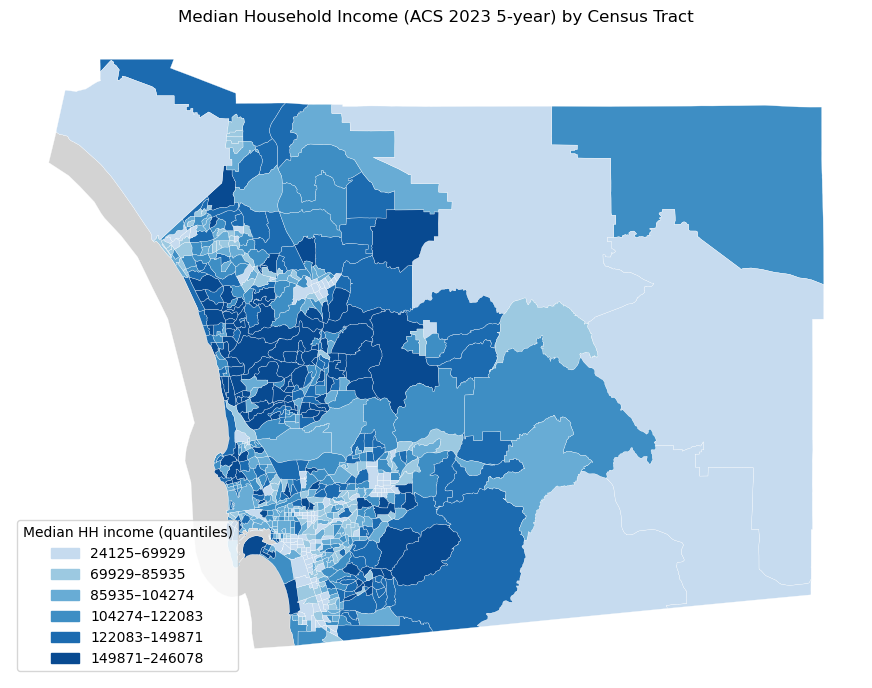

/var/folders/dg/bllrnyzj2fzf93_myxywvnnm0000gn/T/ipykernel_25037/984678982.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(palette)
/var/folders/dg/bllrnyzj2fzf93_myxywvnnm0000gn/T/ipykernel_25037/984678982.py:43: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['-0.0–3.8' '-0.0–3.8' '-0.0–3.8' '16.9–46.7' '11.0–16.9' '11.0–16.9'
 '16.9–46.7' '16.9–46.7' '8.2–11.0' '3.8–5.9' '-0.0–3.8' '16.9–46.7'
 '-0.0–3.8' '5.9–8.2' '5.9–8.2' '3.8–5.9' '11.0–16.9' '16.9–46.7'
 '3.8–5.9' '5.9–8.2' '3.8–5.9' '3.8–5.9' '5.9–8.2' '11.0–16.9' '16.9–46.7'
 '16.9–46.7' '16.9–46.7' '3.8–5.9' '5.9–8.2' '11.0–16.9' '8.2–11.0'
 '5.9–8.2' '5.9–8.2' '5.9–8.2' '11.0–16.9' '16.9–46.7' '16.9–46.7'
 '-0.0–3.8' '5.9–8.2' '8.2–11.0' '5.9–8.

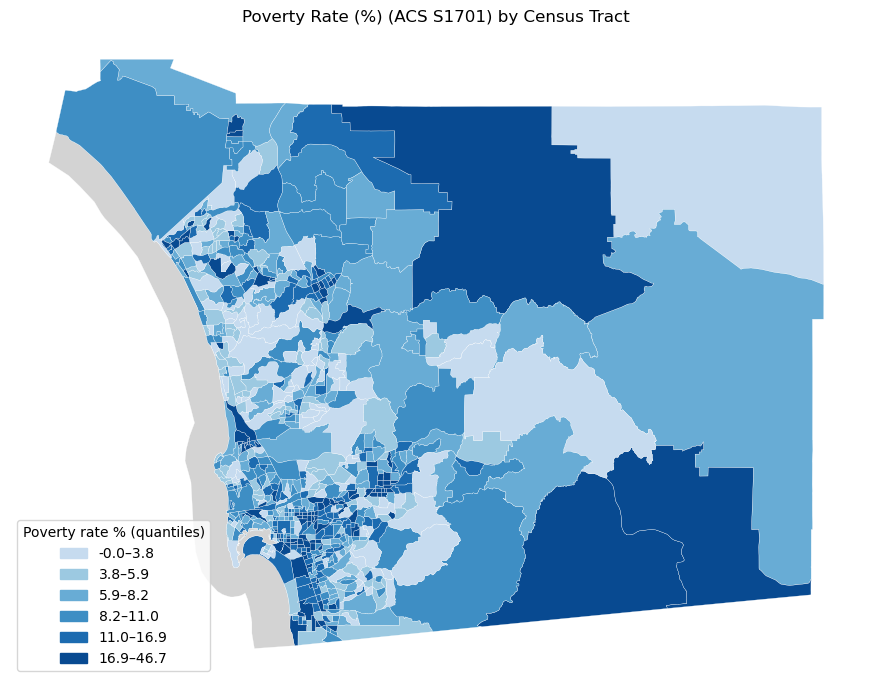

/var/folders/dg/bllrnyzj2fzf93_myxywvnnm0000gn/T/ipykernel_25037/984678982.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(palette)
/var/folders/dg/bllrnyzj2fzf93_myxywvnnm0000gn/T/ipykernel_25037/984678982.py:43: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['1.0–2.3' '1.0–2.3' '-0.0–1.0' '2.3–3.7' '5.7–9.6' '9.6–100.0' '5.7–9.6'
 '-0.0–1.0' '2.3–3.7' '-0.0–1.0' '9.6–100.0' '5.7–9.6' '-0.0–1.0'
 '3.7–5.7' '1.0–2.3' '1.0–2.3' '3.7–5.7' '5.7–9.6' '3.7–5.7' '5.7–9.6'
 '2.3–3.7' '3.7–5.7' '3.7–5.7' '9.6–100.0' '9.6–100.0' '9.6–100.0'
 '3.7–5.7' '2.3–3.7' '2.3–3.7' '5.7–9.6' '5.7–9.6' '5.7–9.6' '3.7–5.7'
 '-0.0–1.0' '9.6–100.0' '9.6–100.0' '3.7–5.7' '3.7–5.7' '1.0–2.3'
 '3.7–5.7' '-0.0–1.0' '-0.0–1.0' '5.7–9.

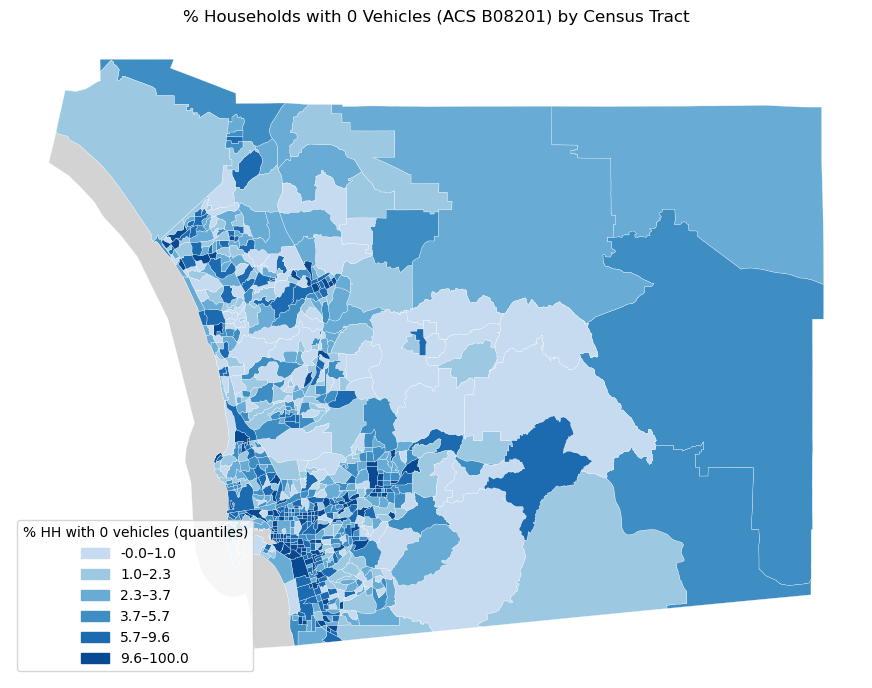

/var/folders/dg/bllrnyzj2fzf93_myxywvnnm0000gn/T/ipykernel_25037/984678982.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(palette)
/var/folders/dg/bllrnyzj2fzf93_myxywvnnm0000gn/T/ipykernel_25037/984678982.py:43: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['-0.0–0.7' '-0.0–0.7' '-0.0–0.7' '7.7–23.8' '7.7–23.8' '7.7–23.8'
 '4.8–7.7' '0.7–1.7' '4.8–7.7' '1.7–3.0' '7.7–23.8' '-0.0–0.7' '0.7–1.7'
 '1.7–3.0' '1.7–3.0' '7.7–23.8' '1.7–3.0' '3.0–4.8' '0.7–1.7' '1.7–3.0'
 '1.7–3.0' '0.7–1.7' '1.7–3.0' '4.8–7.7' '7.7–23.8' '3.0–4.8' '4.8–7.7'
 '3.0–4.8' '1.7–3.0' '1.7–3.0' '4.8–7.7' '3.0–4.8' '0.7–1.7' '4.8–7.7'
 '4.8–7.7' '7.7–23.8' '3.0–4.8' '1.7–3.0' '1.7–3.0' '3.0–4.8' '1.7–3.0'
 '-0.0–0.7' '-0.0–0.7' '4.8–

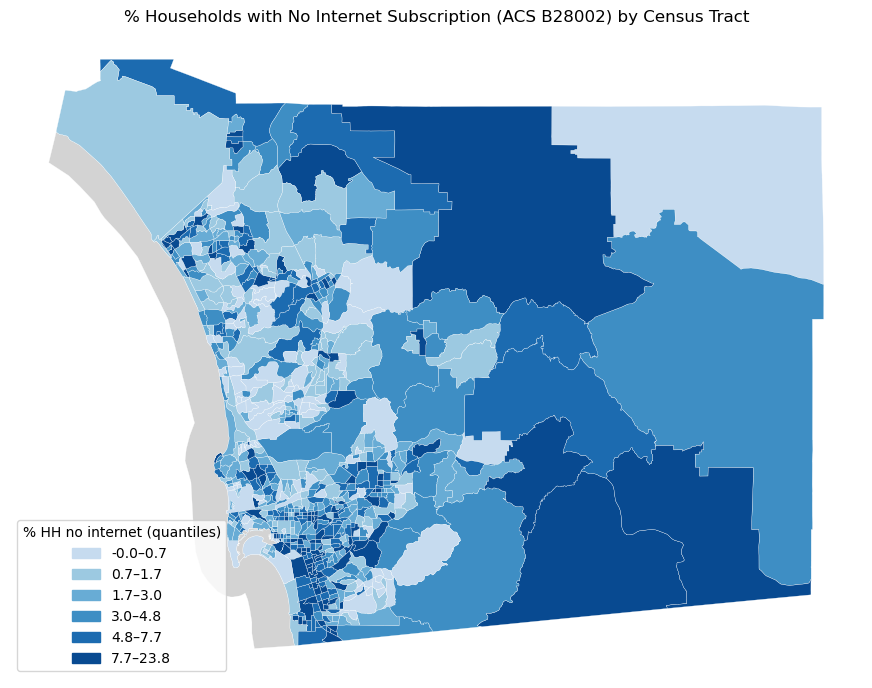

/var/folders/dg/bllrnyzj2fzf93_myxywvnnm0000gn/T/ipykernel_25037/984678982.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(palette)
/var/folders/dg/bllrnyzj2fzf93_myxywvnnm0000gn/T/ipykernel_25037/984678982.py:43: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['82–100' '82–100' '82–100' '-0–41' '-0–41' '-0–41' '-0–41' '56–66'
 '56–66' '74–82' '-0–41' '41–56' '82–100' '56–66' '74–82' '56–66' '41–56'
 '-0–41' '74–82' '66–74' '74–82' '74–82' '74–82' '-0–41' '-0–41' '-0–41'
 '41–56' '74–82' '66–74' '56–66' '56–66' '56–66' '66–74' '66–74' '41–56'
 '-0–41' '-0–41' '66–74' '66–74' '56–66' '74–82' '82–100' '66–74' '41–56'
 '56–66' '56–66' '-0–41' '66–74' '41–56' '41–56' '-0–41' '-0–41' '56–66'
 '56–66' '56–66' '41

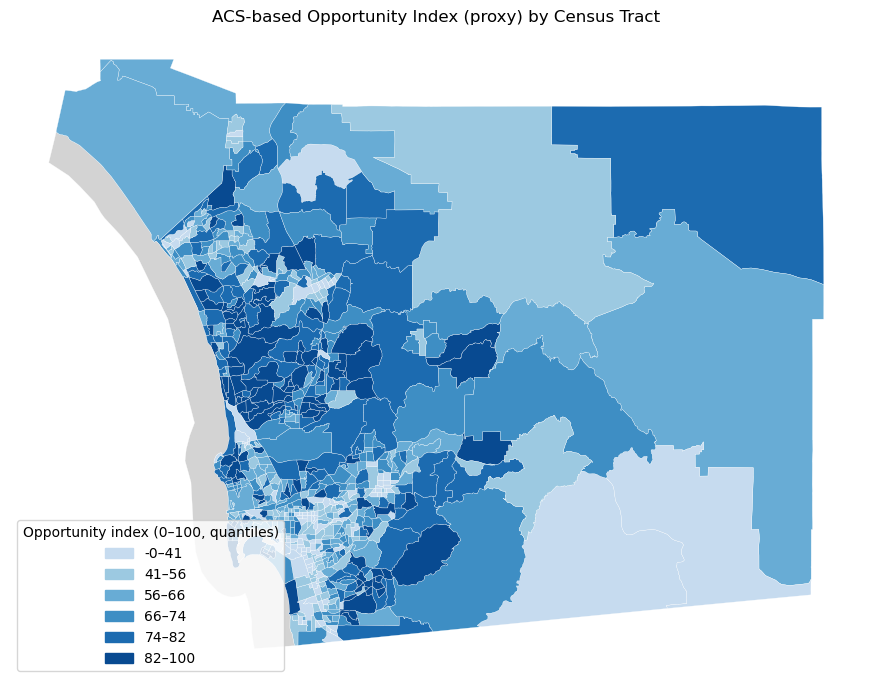

In [148]:
# Plots
if "median_hh_income" in tract_ind.columns:
    plot_tableau_quantile_bins(
        tract_ind, "median_hh_income",
        title="Median Household Income (ACS 2023 5-year) by Census Tract",
        legend_title="Median HH income (quantiles)",
        fmt="{:.0f}"
    )

if "poverty_rate_pct" in tract_ind.columns:
    plot_tableau_quantile_bins(
        tract_ind, "poverty_rate_pct",
        title="Poverty Rate (%) (ACS S1701) by Census Tract",
        legend_title="Poverty rate % (quantiles)",
        fmt="{:.1f}"
    )

if "pct_hh_zero_vehicle" in tract_ind.columns:
    plot_tableau_quantile_bins(
        tract_ind, "pct_hh_zero_vehicle",
        title="% Households with 0 Vehicles (ACS B08201) by Census Tract",
        legend_title="% HH with 0 vehicles (quantiles)",
        fmt="{:.1f}"
    )

if "pct_hh_no_internet" in tract_ind.columns:
    plot_tableau_quantile_bins(
        tract_ind, "pct_hh_no_internet",
        title="% Households with No Internet Subscription (ACS B28002) by Census Tract",
        legend_title="% HH no internet (quantiles)",
        fmt="{:.1f}"
    )

if "opportunity_index_acs" in tract_ind.columns:
    plot_tableau_quantile_bins(
        tract_ind, "opportunity_index_acs",
        title="ACS-based Opportunity Index (proxy) by Census Tract",
        legend_title="Opportunity index (0–100, quantiles)",
        fmt="{:.0f}"
    )

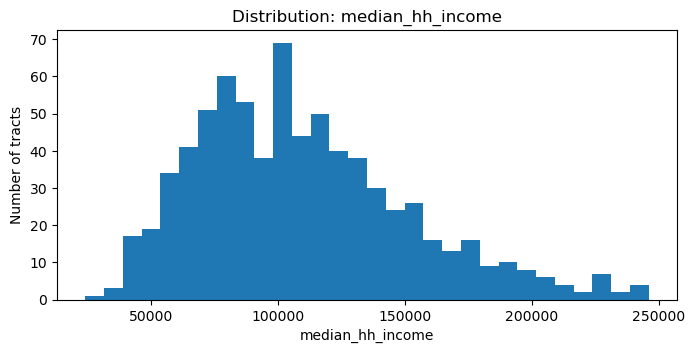

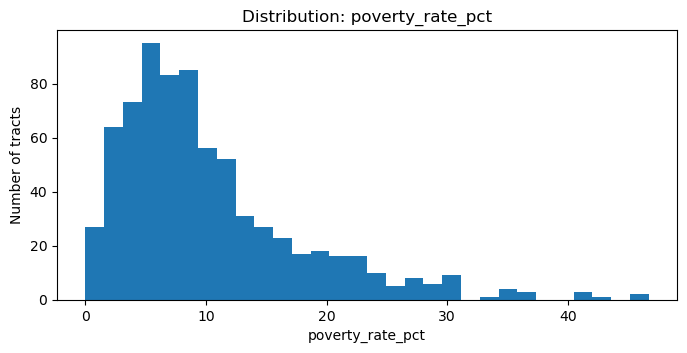

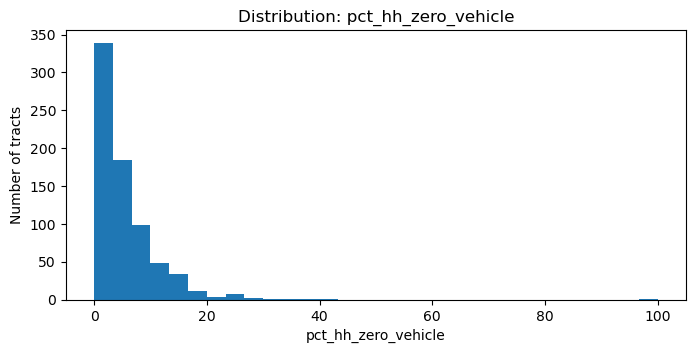

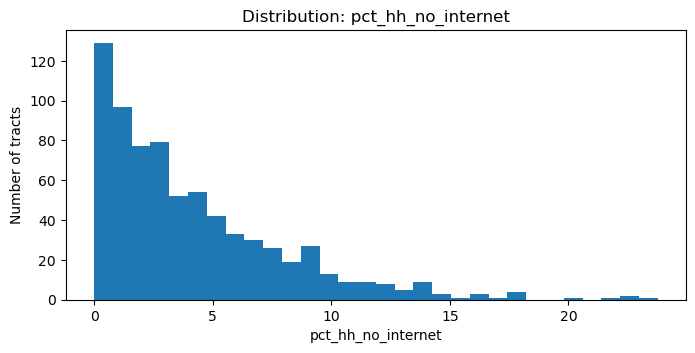

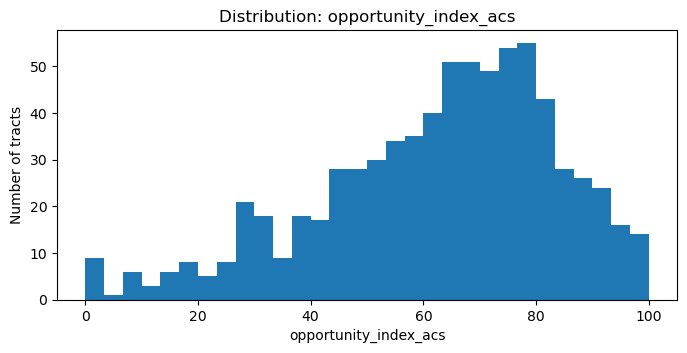

In [149]:
# Quick distribution histograms 
numeric_cols = [
    c for c in ["median_hh_income", "poverty_rate_pct", "pct_hh_zero_vehicle", "pct_hh_no_internet", "opportunity_index_acs"]
    if c in tract_ind.columns
]

for c in numeric_cols:
    vals = pd.to_numeric(tract_ind[c], errors="coerce").dropna()
    if vals.empty:
        continue
    plt.figure(figsize=(8, 3.5))
    plt.hist(vals, bins=30)
    plt.title(f"Distribution: {c}")
    plt.xlabel(c)
    plt.ylabel("Number of tracts")
    plt.show()


In [150]:
# Interactive map (folium) with tract tooltips
center_lat = float(tracts_sd.to_crs("EPSG:4326").geometry.centroid.y.median())
center_lon = float(tracts_sd.to_crs("EPSG:4326").geometry.centroid.x.median())
m = folium.Map(location=[center_lat, center_lon], zoom_start=10, control_scale=True)

def add_folium_choropleth(map_obj, gdf, value_col, layer_name):
    if value_col not in gdf.columns:
        return

    tmp = gdf[["tract_geoid", value_col, "geometry"]].copy()
    tmp[value_col] = pd.to_numeric(tmp[value_col], errors="coerce")

    folium.Choropleth(
        geo_data=tmp,
        data=tmp,
        columns=["tract_geoid", value_col],
        key_on="feature.properties.tract_geoid",
        name=layer_name,
        fill_opacity=0.9,
        line_opacity=0.2,
        legend_name=layer_name,
        show=False,
    ).add_to(map_obj)

    folium.GeoJson(
        tmp,
        name=f"{layer_name} (tooltip)",
        style_function=lambda x: {
        "fillOpacity": 0,
        "fillColor": "transparent",
        "weight": 0.6,          
        "color": "#333333"
    },
        tooltip=folium.features.GeoJsonTooltip(
            fields=["tract_geoid", value_col],
            aliases=["tract_geoid: ", f"{value_col}: "],
            sticky=False
        ),
        show=False
    ).add_to(map_obj)

for c in numeric_cols:
    add_folium_choropleth(m, tract_ind, c, f"{c}")

folium.LayerControl(collapsed=False).add_to(m)

m.save(str(OUT_HTML))
print("Saved:", OUT_HTML)

Saved: /Users/laurenvo/Documents/github/Mapping-Youth-Opportunity-Deserts/data/processed/acs/acs_tract_maps.html


In [151]:
print("\nMissingness by indicator:")
summary = {}
for c in numeric_cols:
    summary[c] = {
        "missing": int(pd.to_numeric(tract_ind[c], errors="coerce").isna().sum()),
        "total": int(len(tract_ind)),
        "pct_missing": float(pd.to_numeric(tract_ind[c], errors="coerce").isna().mean())
    }

display(pd.DataFrame(summary).T.sort_values("pct_missing", ascending=False))


Missingness by indicator:


,missing,total,pct_missing
median_hh_income,2.0,737.0,0.002714
poverty_rate_pct,2.0,737.0,0.002714
pct_hh_zero_vehicle,2.0,737.0,0.002714
pct_hh_no_internet,2.0,737.0,0.002714
opportunity_index_acs,2.0,737.0,0.002714
